In [1]:
import pandas as pd

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\amit6\OneDrive\Desktop\Intelligent-Retail-Customer-Analytics\Data\Processed_data\retail_feature_engineered.csv")
df.head()

C:\Users\amit6\AppData\Local\Temp\ipykernel_15108\3849823998.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\amit6\OneDrive\Desktop\Intelligent-Retail-Customer-Analytics\Data\Processed_data\retail_feature_engineered.csv")


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount,Year,...,Hour,IsWeekend,InvoiceTotal,BasketSize,PurchaseFrequency,AverageOrderValue,CustomerRevenue,ProductPurchaseCount,ProductRevenue,CustomerType
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,...,7,False,505.3,8,8.0,350.900238,2433.28,522,21201.13,Regular
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,...,7,False,505.3,8,8.0,350.900238,2433.28,266,13787.93,Regular
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,...,7,False,505.3,8,8.0,350.900238,2433.28,350,18048.72,Regular
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,...,7,False,505.3,8,8.0,350.900238,2433.28,560,18650.87,Regular
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,...,7,False,505.3,8,8.0,350.900238,2433.28,2478,49300.57,Regular


In [3]:
basket = df[["Invoice","Description"]].copy()

In [4]:
basket = df[df["Quantity"] > 0][["Invoice","Description"]]

In [5]:
basket = basket.dropna()

In [6]:
basket = (
    basket
    .groupby(["Invoice","Description"])["Description"]
    .count()
    .unstack()
    .fillna(0)
)

In [7]:
basket = basket.map(lambda x: 1 if x > 0 else 0)

In [8]:
frequent_items = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

c:\Users\amit6\AppData\Local\Programs\Python\Python314\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [9]:
rules = association_rules(
    frequent_items,
    metric="lift",
    min_threshold=1
)

In [10]:
rules = rules.sort_values(

    by="lift",

    ascending=False
)

In [11]:
rules[[
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift"
]].head(20)

,antecedents,consequents,support,confidence,lift
7,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.021308,0.833984,24.944224
6,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.021308,0.637313,24.944224
41,(PINK REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER ),0.020060,0.785156,22.317927
40,(ROSES REGENCY TEACUP AND SAUCER ),(PINK REGENCY TEACUP AND SAUCER),0.020060,0.570213,22.317927
8,(ROSES REGENCY TEACUP AND SAUCER ),(GREEN REGENCY TEACUP AND SAUCER),0.025525,0.725532,21.700443
9,(GREEN REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER ),0.025525,0.763433,21.700443
2,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED ),0.020859,0.656716,19.310739
3,(ALARM CLOCK BAKELIKE RED ),(ALARM CLOCK BAKELIKE GREEN),0.020859,0.613353,19.310739
4,(DOLLY GIRL LUNCH BOX),(SPACEBOY LUNCH BOX ),0.020684,0.621905,18.220285
5,(SPACEBOY LUNCH BOX ),(DOLLY GIRL LUNCH BOX),0.020684,0.605994,18.220285


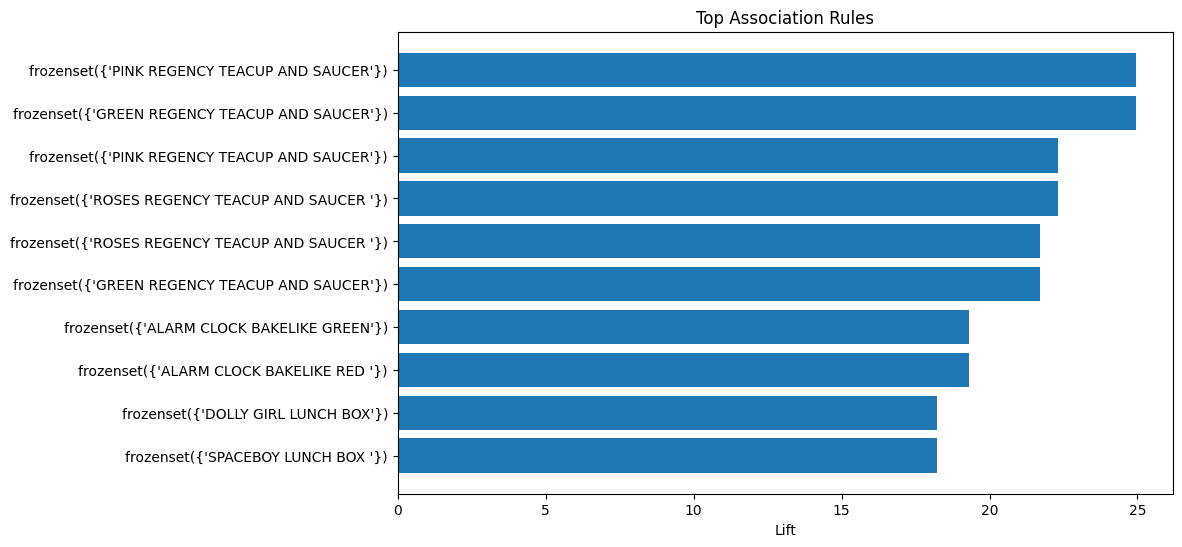

In [12]:
top10 = rules.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    range(len(top10)),
    top10["lift"]
)

plt.yticks(
    range(len(top10)),
    top10["antecedents"].astype(str)
)

plt.xlabel("Lift")

plt.title("Top Association Rules")

plt.gca().invert_yaxis()

plt.show()

- Customers purchasing Product A are 3.8× more likely to purchase Product B.
- Bundling Product X and Product Y can increase cross-selling opportunities.
- Products with the highest lift are ideal candidates for recommendation engines.
- Retailers can use these associations to optimize product placement and promotional campaigns.

In [13]:
rules.to_csv("association_rules.csv", index=False)
frequent_items.to_csv("frequent_itemsets.csv", index=False)

print("Association rules and frequent itemsets saved successfully!")

Association rules and frequent itemsets saved successfully!


In [14]:
df1 = pd.read_csv(r"C:\Users\amit6\OneDrive\Desktop\Intelligent-Retail-Customer-Analytics\Data\Processed_data\customer_feature_store.csv")
df.isnull().sum()

Invoice                      0
StockCode                    0
Description                  0
Quantity                     0
InvoiceDate                  0
Price                        0
Customer ID             228488
Country                      0
TotalAmount                  0
Year                         0
Month                        0
MonthName                    0
Quarter                      0
Day                          0
DayName                      0
Hour                         0
IsWeekend                    0
InvoiceTotal                 0
BasketSize                   0
PurchaseFrequency       228488
AverageOrderValue       228488
CustomerRevenue         228488
ProductPurchaseCount         0
ProductRevenue               0
CustomerType            228488
dtype: int64

In [15]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'TotalAmount', 'Year', 'Month',
       'MonthName', 'Quarter', 'Day', 'DayName', 'Hour', 'IsWeekend',
       'InvoiceTotal', 'BasketSize', 'PurchaseFrequency', 'AverageOrderValue',
       'CustomerRevenue', 'ProductPurchaseCount', 'ProductRevenue',
       'CustomerType'],
      dtype='object')

In [16]:
df.shape

(1007913, 25)